# PCA Dimensions XGBoost Classifier

Trains an **XGBoost** classifier on the principal components of the
raw `SelfAttention.o` activation vectors to detect hallucination.

Key questions answered:
- How does XGBoost AUC change as we add more PCA components?
- What is the ceiling AUC after hyperparameter optimisation with hyperopt?
- What does the decision boundary look like in PC1+PC2 space?

Data acquisition is identical to `pca_scatter_from_mongo.ipynb`.

## Cell 1 — Imports

In [1]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import optuna
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from scipy.spatial import ConvexHull
from xgboost import XGBClassifier

from neuralsignal.backend.ns_backend import NSBackend

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Imports OK")

Imports OK


## Cell 2 — Config

In [2]:
APPLICATION_NAME     = "redis"
SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

GROUP_SIZE   = 50
HALF         = GROUP_SIZE // 2   # loaded equally from ground_truth=0 and ground_truth=1
LAYER_INDEX  = -2    # penultimate SelfAttention.o layer
N_COMPONENTS = 20    # fit up to 20 PCA components
CV_FOLDS     = 5     # stratified k-fold cross-validation
RANDOM_STATE = 42

# Each class is loaded from two sub-filters (gt=0 and gt=1) in equal halves,
# so the classifier cannot exploit ground_truth value as a spurious feature.
FILTER_CORRECT_GT0      = {"ground_truth": "0", "decoded_output": {"$regex": "^Fal"}}
FILTER_CORRECT_GT1      = {"ground_truth": "1", "decoded_output": {"$regex": "^True"}}
FILTER_HALLUCINATED_GT0 = {"ground_truth": "0", "decoded_output": {"$regex": "^True"}}
FILTER_HALLUCINATED_GT1 = {"ground_truth": "1", "decoded_output": {"$regex": "^Fal"}}

## Cell 3 — Connect to backend & load scan groups

In [3]:
import tempfile
from neuralsignal.core.modules.neuralsignal_config import sdk_config

backend_cfg = sdk_config.get_backend_config()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

def load_group(be, filter_a, filter_b, n_each):
    """Load n_each scans from filter_a and n_each from filter_b, combined."""
    scans = []
    for f in [filter_a, filter_b]:
        cursor = be.query(f).limit(n_each)
        for doc in cursor:
            try:
                scans.append(be.deserialize_scan(doc))
            except Exception as e:
                print(f"  skipping {doc.get('_id')}: {e}")
    return scans

print(f"Loading correct group ({HALF} gt=0 + {HALF} gt=1) ...")
group_correct = load_group(be, FILTER_CORRECT_GT0, FILTER_CORRECT_GT1, HALF)
print(f"  loaded {len(group_correct)} scans")

print(f"Loading hallucinated group ({HALF} gt=0 + {HALF} gt=1) ...")
group_hallucinated = load_group(be, FILTER_HALLUCINATED_GT0, FILTER_HALLUCINATED_GT1, HALF)
print(f"  loaded {len(group_hallucinated)} scans")

Loading correct group (25 gt=0 + 25 gt=1) ...
  loaded 50 scans
Loading hallucinated group (25 gt=0 + 25 gt=1) ...
  loaded 50 scans


## Cell 4 — Extract activation vectors & build label array

In [4]:
def extract_layer_vector(scan, layer_index):
    layer_id_to_name = scan["layer_id_to_name"]
    sa_layers = [
        lid for lid in scan["layer_order"]
        if "SelfAttention.o" in layer_id_to_name[lid]
    ]
    if not sa_layers:
        raise ValueError("No SelfAttention.o layers found.")
    lid = sa_layers[layer_index]
    tensor = scan["outputs"][lid]
    return tensor[-1, :].float(), layer_id_to_name[lid]

def build_matrix(scans, layer_index, expected_dim=None):
    vectors, skipped = [], 0
    for scan in scans:
        try:
            vec, _ = extract_layer_vector(scan, layer_index)
            if expected_dim is not None and vec.shape[0] != expected_dim:
                skipped += 1
                continue
            vectors.append(vec)
        except Exception:
            skipped += 1
    if skipped:
        print(f"  skipped {skipped} scans")
    return torch.stack(vectors)

vecs_correct      = build_matrix(group_correct,      LAYER_INDEX)
vecs_hallucinated = build_matrix(group_hallucinated, LAYER_INDEX,
                                 expected_dim=vecs_correct.shape[1])

_, layer_name = extract_layer_vector(group_correct[0], LAYER_INDEX)
print(f"Layer       : {layer_name}")
print(f"Correct     : {vecs_correct.shape}")
print(f"Hallucinated: {vecs_hallucinated.shape}")

# 0 = correct prediction, 1 = hallucinated (model output disagrees with ground truth)
X_raw = np.vstack([vecs_correct.numpy(), vecs_hallucinated.numpy()])
y     = np.array([0] * len(vecs_correct) + [1] * len(vecs_hallucinated))
print(f"\nX_raw : {X_raw.shape}")
print(f"y     : {y.shape}  ({(y==0).sum()} correct, {(y==1).sum()} hallucinated)")

Layer       : decoder.T5Block.T5LayerSelfAttention.SelfAttention.o
Correct     : torch.Size([50, 1024])
Hallucinated: torch.Size([50, 1024])

X_raw : (100, 1024)
y     : (100,)  (50 correct, 50 hallucinated)


## Cell 5 — Fit PCA on combined data

In [5]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_raw)   # (N, N_COMPONENTS)

var = pca.explained_variance_ratio_ * 100
print("Explained variance:")
for i, v in enumerate(var):
    cumulative = var[:i+1].sum()
    print(f"  PC{i+1:>2}: {v:5.1f}%   cumulative: {cumulative:5.1f}%")

Explained variance:
  PC 1:  70.5%   cumulative:  70.5%
  PC 2:  13.0%   cumulative:  83.5%
  PC 3:   5.6%   cumulative:  89.1%
  PC 4:   1.2%   cumulative:  90.3%
  PC 5:   0.9%   cumulative:  91.1%
  PC 6:   0.6%   cumulative:  91.8%
  PC 7:   0.5%   cumulative:  92.3%
  PC 8:   0.5%   cumulative:  92.8%
  PC 9:   0.4%   cumulative:  93.2%
  PC10:   0.4%   cumulative:  93.6%
  PC11:   0.4%   cumulative:  94.0%
  PC12:   0.3%   cumulative:  94.3%
  PC13:   0.3%   cumulative:  94.6%
  PC14:   0.3%   cumulative:  94.9%
  PC15:   0.3%   cumulative:  95.2%
  PC16:   0.3%   cumulative:  95.4%
  PC17:   0.2%   cumulative:  95.7%
  PC18:   0.2%   cumulative:  95.9%
  PC19:   0.2%   cumulative:  96.1%
  PC20:   0.2%   cumulative:  96.3%


## Cell 6 — XGBoost: cross-validated AUC vs number of components

Sweeps k=1..N_COMPONENTS with default XGBoost hyperparameters to find where
diminishing returns kick in. PCA is inside a Pipeline so it is re-fit per fold.

In [6]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

aucs, accs, auc_stds, acc_stds = [], [], [], []

for k in range(1, N_COMPONENTS + 1):
    pipe = Pipeline([
        ("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
        ("clf", XGBClassifier(
            n_estimators=100,
            verbosity=0,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
        )),
    ])
    results = cross_validate(pipe, X_raw, y, cv=cv,
                             scoring=["roc_auc", "accuracy"],
                             return_train_score=False)
    aucs.append(results["test_roc_auc"].mean())
    auc_stds.append(results["test_roc_auc"].std())
    accs.append(results["test_accuracy"].mean())
    acc_stds.append(results["test_accuracy"].std())
    print(f"  k={k:>2}  AUC={aucs[-1]:.4f} ± {auc_stds[-1]:.4f}   Acc={accs[-1]:.4f} ± {acc_stds[-1]:.4f}")

aucs     = np.array(aucs)
auc_stds = np.array(auc_stds)
accs     = np.array(accs)
acc_stds = np.array(acc_stds)

best_k_auc = int(np.argmax(aucs)) + 1
print(f"\nBest AUC : {aucs.max():.4f} at k={best_k_auc}")
print(f"PC1+PC2  : AUC={aucs[1]:.4f}   Accuracy={accs[1]:.4f}")

  k= 1  AUC=0.6610 ± 0.0908   Acc=0.6300 ± 0.1030
  k= 2  AUC=0.7180 ± 0.1130   Acc=0.6600 ± 0.0800
  k= 3  AUC=0.6920 ± 0.1418   Acc=0.6500 ± 0.1581
  k= 4  AUC=0.7020 ± 0.1422   Acc=0.6800 ± 0.1208
  k= 5  AUC=0.6720 ± 0.1587   Acc=0.6400 ± 0.1114
  k= 6  AUC=0.7060 ± 0.1592   Acc=0.6600 ± 0.1319
  k= 7  AUC=0.6640 ± 0.1500   Acc=0.6200 ± 0.1166
  k= 8  AUC=0.6520 ± 0.1669   Acc=0.6600 ± 0.1319
  k= 9  AUC=0.6700 ± 0.1435   Acc=0.6400 ± 0.1497
  k=10  AUC=0.6540 ± 0.1524   Acc=0.6300 ± 0.1400
  k=11  AUC=0.6720 ± 0.1694   Acc=0.6500 ± 0.1517
  k=12  AUC=0.6720 ± 0.1735   Acc=0.6200 ± 0.1536
  k=13  AUC=0.6660 ± 0.1693   Acc=0.6600 ± 0.1530
  k=14  AUC=0.6620 ± 0.1613   Acc=0.6300 ± 0.1327
  k=15  AUC=0.6680 ± 0.1674   Acc=0.6200 ± 0.1288
  k=16  AUC=0.6360 ± 0.1783   Acc=0.6000 ± 0.1483
  k=17  AUC=0.6480 ± 0.1473   Acc=0.5900 ± 0.1281
  k=18  AUC=0.6340 ± 0.1794   Acc=0.6300 ± 0.1166
  k=19  AUC=0.6680 ± 0.1419   Acc=0.6400 ± 0.1068
  k=20  AUC=0.6780 ± 0.1473   Acc=0.6500 ± 0.1304


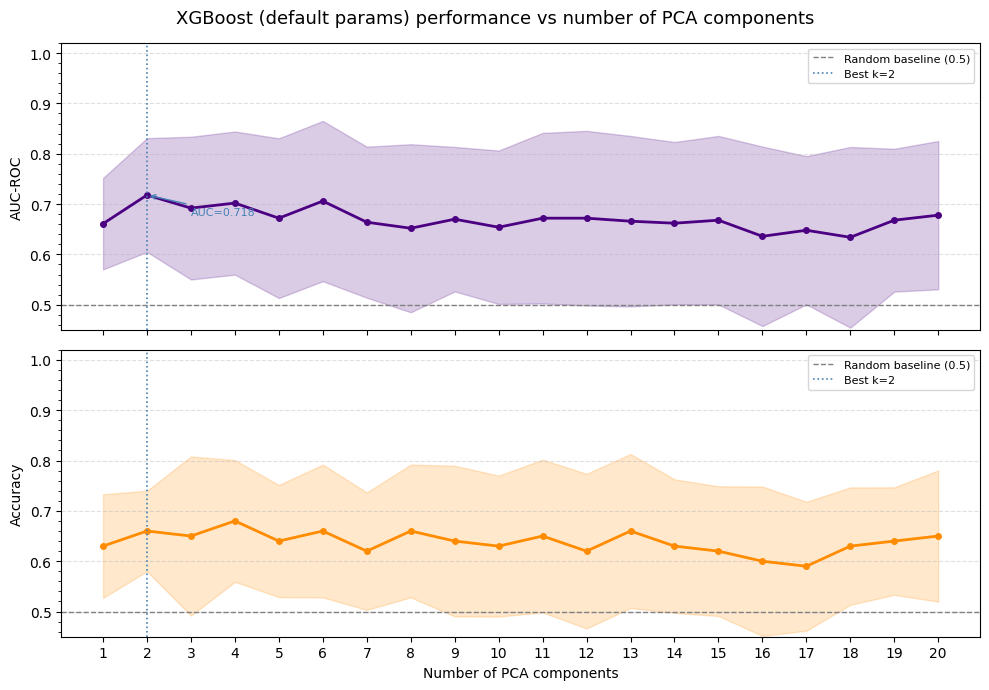

In [7]:
k_range = np.arange(1, N_COMPONENTS + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("XGBoost (default params) performance vs number of PCA components", fontsize=13)

ax1.plot(k_range, aucs, color="indigo", linewidth=2, marker="o", markersize=4)
ax1.fill_between(k_range, aucs - auc_stds, aucs + auc_stds, alpha=0.2, color="indigo")
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline (0.5)")
ax1.axvline(best_k_auc, color="steelblue", linestyle=":", linewidth=1.2,
            label=f"Best k={best_k_auc}")
ax1.set_ylabel("AUC-ROC")
ax1.set_ylim(0.45, 1.02)
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend(fontsize=8)
ax1.annotate(f"AUC={aucs[best_k_auc-1]:.3f}",
             xy=(best_k_auc, aucs[best_k_auc-1]),
             xytext=(best_k_auc + 1, aucs[best_k_auc-1] - 0.04),
             arrowprops=dict(arrowstyle="->", color="steelblue"),
             fontsize=8, color="steelblue")

ax2.plot(k_range, accs, color="darkorange", linewidth=2, marker="o", markersize=4)
ax2.fill_between(k_range, accs - acc_stds, accs + acc_stds, alpha=0.2, color="darkorange")
ax2.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline (0.5)")
ax2.axvline(best_k_auc, color="steelblue", linestyle=":", linewidth=1.2,
            label=f"Best k={best_k_auc}")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.45, 1.02)
ax2.set_xlabel("Number of PCA components")
ax2.set_xticks(k_range)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Cell 6b — Hyperparameter optimisation with optuna

Runs TPE-based Bayesian optimisation over XGBoost hyperparameters using
`best_k_auc` components from the sweep above.  Each trial is scored with the
same 5-fold stratified CV so the search metric is directly comparable to Cell 6.

Note: with only 100 samples this search can overfit the validation splits —
treat the resulting AUC as an upper bound rather than a production estimate.

In [8]:
HYPEROPT_EVALS = 100   # increase for a more thorough search

def optuna_objective(trial):
    params = {
        "max_depth":        trial.suggest_int("max_depth",        2, 9),
        "n_estimators":     trial.suggest_int("n_estimators",     50, 500),
        "learning_rate":    trial.suggest_float("learning_rate",  0.01, 0.4, log=True),
        "subsample":        trial.suggest_float("subsample",      0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "gamma":            trial.suggest_float("gamma",          0.0, 4.0),
        "reg_alpha":        trial.suggest_float("reg_alpha",      1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda",     1e-3, 10.0, log=True),
    }
    pipe = Pipeline([
        ("pca", PCA(n_components=best_k_auc, random_state=RANDOM_STATE)),
        ("clf", XGBClassifier(
            **params,
            verbosity=0,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
        )),
    ])
    return cross_val_score(pipe, X_raw, y, cv=cv, scoring="roc_auc").mean()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(optuna_objective, n_trials=HYPEROPT_EVALS, show_progress_bar=True)

best_params  = study.best_params
best_auc_opt = study.best_value

print(f"\nHyperopt best AUC : {best_auc_opt:.4f}  (k={best_k_auc} components)")
print(f"Default  best AUC : {aucs.max():.4f}  (k={best_k_auc} components)")
print("\nBest hyperparameters:")
for k, v in sorted(best_params.items()):
    print(f"  {k:<22}: {v}")

  0%|          | 0/100 [00:00<?, ?it/s]


Hyperopt best AUC : 0.7130  (k=2 components)
Default  best AUC : 0.7180  (k=2 components)

Best hyperparameters:
  colsample_bytree      : 0.5032526007872017
  gamma                 : 3.467379697731142
  learning_rate         : 0.07318592579218715
  max_depth             : 4
  min_child_weight      : 3
  n_estimators          : 232
  reg_alpha             : 0.23929971206414125
  reg_lambda            : 0.0016487680187959371
  subsample             : 0.7607863001750055


## Cell 7 — ROC curve for the optimised XGBoost classifier

Rebuilds the best pipeline from hyperopt and generates honest out-of-fold
probabilities via `cross_val_predict`, then plots the ROC curve.

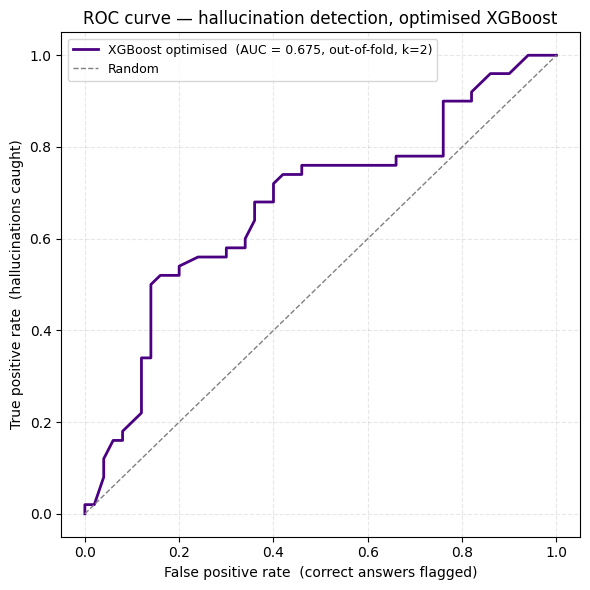

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pca', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg

In [9]:
pipe_opt = Pipeline([
    ("pca", PCA(n_components=best_k_auc, random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(
        **best_params,
        verbosity=0,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
    )),
])

# Honest out-of-fold probabilities
y_prob = cross_val_predict(pipe_opt, X_raw, y, cv=cv, method="predict_proba")[:, 1]

fpr, tpr, _ = roc_curve(y, y_prob)
auc_oof = roc_auc_score(y, y_prob)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="indigo", linewidth=2,
        label=f"XGBoost optimised  (AUC = {auc_oof:.3f}, out-of-fold, k={best_k_auc})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random")
ax.set_xlabel("False positive rate  (correct answers flagged)")
ax.set_ylabel("True positive rate  (hallucinations caught)")
ax.set_title("ROC curve — hallucination detection, optimised XGBoost")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Fit on full data for the decision-boundary visualisation in Cell 8
pipe_opt.fit(X_raw, y)

## Cell 8 — Decision boundary overlaid on PCA scatter

Visualises the optimised XGBoost boundary projected onto PC1+PC2.
The model operates in `best_k_auc` dimensions; the mesh is inverse-transformed
from 2D PC space back to raw space before calling `predict_proba`, so the
boundary shown is a cross-section of the full decision surface.
Fit is on all data — visualisation only; honest AUC is from Cell 7.

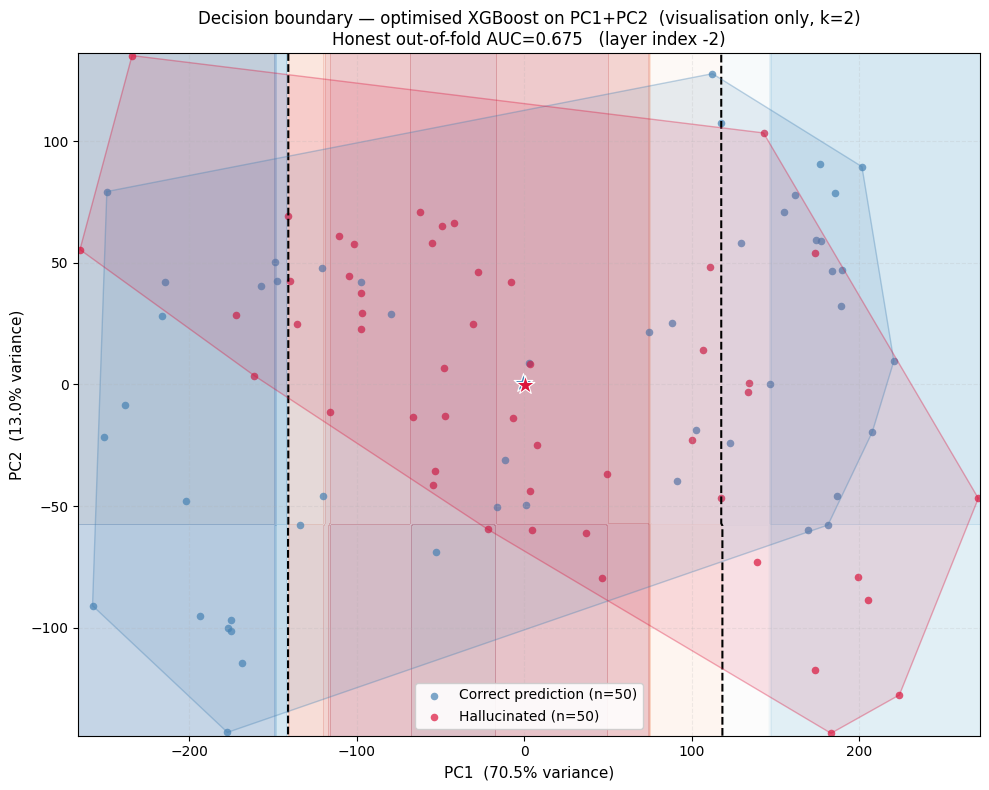

In [10]:
def draw_convex_hull(ax, points, color, alpha=0.12):
    if len(points) < 3:
        return
    try:
        hull = ConvexHull(points)
        vertices = np.append(hull.vertices, hull.vertices[0])
        ax.fill(points[vertices, 0], points[vertices, 1],
                color=color, alpha=alpha, linewidth=0)
        ax.plot(points[vertices, 0], points[vertices, 1],
                color=color, alpha=0.35, linewidth=1)
    except Exception:
        pass

# Project all data to PC1+PC2 using the full-data PCA inside pipe_opt
pca_viz = pipe_opt.named_steps["pca"]
X_pca_viz = pca_viz.transform(X_raw)   # shape (N, best_k_auc)

proj_correct      = X_pca_viz[y == 0, :2]
proj_hallucinated = X_pca_viz[y == 1, :2]

# Build a 2D mesh, back-project to raw space (remaining PCs set to 0),
# then score with the full optimised pipeline.
x_min, x_max = X_pca_viz[:, 0].min() - 1, X_pca_viz[:, 0].max() + 1
y_min, y_max = X_pca_viz[:, 1].min() - 1, X_pca_viz[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

mesh_pc = np.zeros((xx.size, best_k_auc))
mesh_pc[:, 0] = xx.ravel()
mesh_pc[:, 1] = yy.ravel()
mesh_raw = pca_viz.inverse_transform(mesh_pc)
Z = pipe_opt.predict_proba(mesh_raw)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))

ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.25)
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5, linestyles="--")

ax.scatter(proj_correct[:, 0], proj_correct[:, 1],
           c="steelblue", s=30, alpha=0.7, linewidths=0,
           label=f"Correct prediction (n={len(proj_correct)})")
ax.scatter(proj_hallucinated[:, 0], proj_hallucinated[:, 1],
           c="crimson", s=30, alpha=0.7, linewidths=0,
           label=f"Hallucinated (n={len(proj_hallucinated)})")

draw_convex_hull(ax, proj_correct,      "steelblue")
draw_convex_hull(ax, proj_hallucinated, "crimson")

ax.scatter(*proj_correct.mean(axis=0),      c="steelblue", s=200, marker="*",
           zorder=5, edgecolors="white", linewidths=0.8)
ax.scatter(*proj_hallucinated.mean(axis=0), c="crimson",   s=200, marker="*",
           zorder=5, edgecolors="white", linewidths=0.8)

var = pca_viz.explained_variance_ratio_ * 100
ax.set_xlabel(f"PC1  ({var[0]:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({var[1]:.1f}% variance)", fontsize=11)
ax.set_title(
    f"Decision boundary — optimised XGBoost on PC1+PC2  (visualisation only, k={best_k_auc})\n"
    f"Honest out-of-fold AUC={auc_oof:.3f}   (layer index {LAYER_INDEX})",
    fontsize=12,
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(linestyle="--", alpha=0.2)

plt.tight_layout()
plt.show()